# **Breast Cancer Tumor Prediction comparision btw multiple various ML algos and XGBoost**

**Importing dependecies**

In [144]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

**----- DATA ANALYSIS & PRE PROCESSING-----**

**Loading the dataset and initial data analysis**

In [145]:
dataset = pd.read_csv('dataset.csv')

In [146]:
dataset.head()

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [147]:
dataset.shape

(683, 11)

In [148]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 683 entries, 0 to 682
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Sample code number           683 non-null    int64
 1   Clump Thickness              683 non-null    int64
 2   Uniformity of Cell Size      683 non-null    int64
 3   Uniformity of Cell Shape     683 non-null    int64
 4   Marginal Adhesion            683 non-null    int64
 5   Single Epithelial Cell Size  683 non-null    int64
 6   Bare Nuclei                  683 non-null    int64
 7   Bland Chromatin              683 non-null    int64
 8   Normal Nucleoli              683 non-null    int64
 9   Mitoses                      683 non-null    int64
 10  Class                        683 non-null    int64
dtypes: int64(11)
memory usage: 58.8 KB


**dropping the id column which has no effect**

In [149]:
dataset.drop(columns='Sample code number', axis=1)

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,2
1,5,4,4,5,7,10,3,2,1,2
2,3,1,1,1,2,2,3,1,1,2
3,6,8,8,1,3,4,3,7,1,2
4,4,1,1,3,2,1,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...
678,3,1,1,1,3,2,1,1,1,2
679,2,1,1,1,2,1,1,1,1,2
680,5,10,10,3,7,3,8,10,2,4
681,4,8,6,4,3,4,10,6,1,4


**Separating the training features and the target feature**

In [150]:
X = dataset.iloc[:, :-1]
Y = dataset['Class']

**Analysis of the above separation**

In [151]:
print(X)

     Sample code number  Clump Thickness  ...  Normal Nucleoli  Mitoses
0               1000025                5  ...                1        1
1               1002945                5  ...                2        1
2               1015425                3  ...                1        1
3               1016277                6  ...                7        1
4               1017023                4  ...                1        1
..                  ...              ...  ...              ...      ...
678              776715                3  ...                1        1
679              841769                2  ...                1        1
680              888820                5  ...               10        2
681              897471                4  ...                6        1
682              897471                4  ...                4        1

[683 rows x 10 columns]


In [152]:
print(Y)

0      2
1      2
2      2
3      2
4      2
      ..
678    2
679    2
680    4
681    4
682    4
Name: Class, Length: 683, dtype: int64


**----- BUILDING MODELS -----**

In [153]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=32)

**Analysis of above opearation**

In [154]:
print(X_train.shape)
print(X_test.shape)

(546, 10)
(137, 10)


In [155]:
print(Y_train.shape)
print(Y_test.shape)

(546,)
(137,)


**Initializing the models and training them and finding cross validation score**

DTC 0.9376767676767678 0.02630595148603402
KNN 0.6023232323232324 0.06132984386815147
NB 0.7528619528619529 0.07885619645901785
SVC 0.6501683501683502 0.005501728834467407
LDA 0.956060606060606 0.016720316331402862
LR 0.9634343434343433 0.019857442939847175


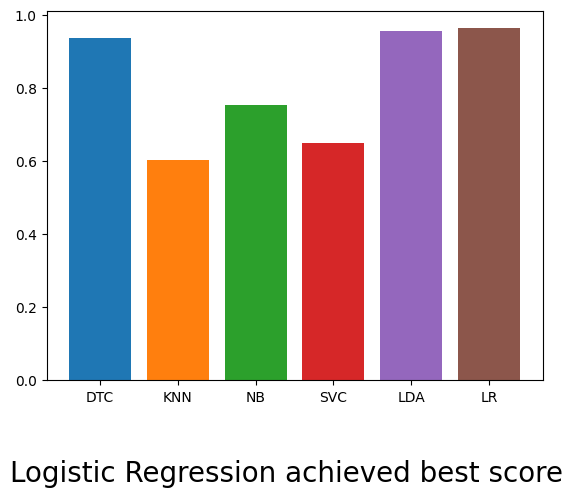

In [188]:
models = {
    'DTC' : DecisionTreeClassifier(),
    'KNN' : KNeighborsClassifier(),
    'NB' : GaussianNB(),
    'SVC' : SVC(gamma='auto'),
    'LDA' : LinearDiscriminantAnalysis(),
    'LR' : LogisticRegression(solver='lbfgs', max_iter=2000)
}

scores = []

for name, model in models.items():
    kfold = StratifiedKFold(n_splits=10, random_state=None)
    cv_score = cross_val_score(model, X_train, Y_train, cv=kfold, scoring='accuracy')
    scores.append(cv_score)
    print(name, cv_score.mean(), cv_score.std())

    plt.bar(x=name, height=cv_score.mean())
plt.figtext(0.5, -0.1, s='Logistic Regression achieved best score', ha='center', fontsize=20)
plt.show()


### **Now performing on same data using XGBoost**

In [157]:
dataset['Target'] = dataset['Class'].apply(lambda x: 0 if x==2 else 1)

In [158]:
dataset['Target'].value_counts()

Target
0    444
1    239
Name: count, dtype: int64

In [173]:
A = dataset.iloc[:, :-2]
B = dataset['Target']

In [174]:
print(A)

     Sample code number  Clump Thickness  ...  Normal Nucleoli  Mitoses
0               1000025                5  ...                1        1
1               1002945                5  ...                2        1
2               1015425                3  ...                1        1
3               1016277                6  ...                7        1
4               1017023                4  ...                1        1
..                  ...              ...  ...              ...      ...
678              776715                3  ...                1        1
679              841769                2  ...                1        1
680              888820                5  ...               10        2
681              897471                4  ...                6        1
682              897471                4  ...                4        1

[683 rows x 10 columns]


In [175]:
XG_train, XG_test, YG_train, YG_test = train_test_split(A, B, test_size=0.2, stratify=B, random_state=32)

In [176]:
XGModel = XGBClassifier()
XGModel.fit(XG_train, YG_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [177]:
y_pred = XGModel.predict(XG_test)

In [178]:
CR = classification_report(YG_test, y_pred)
print(CR)

              precision    recall  f1-score   support

           0       0.99      0.98      0.98        89
           1       0.96      0.98      0.97        48

    accuracy                           0.98       137
   macro avg       0.97      0.98      0.98       137
weighted avg       0.98      0.98      0.98       137



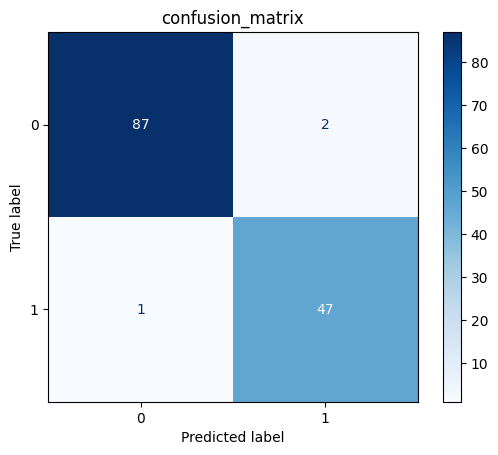

In [179]:
CM = confusion_matrix(YG_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=CM, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title('confusion_matrix')
plt.show()

In [183]:
scores = cross_val_score(XGModel, A, B, cv=kfold, scoring='accuracy')
print(scores.mean())


0.961977834612106


**Comparison: XGBoost achieved more accuracy than other algorithms with boosting extra gradient**

# **Thank You!**